In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns

from sources.donnees.chargeur_donnees import creer_data_loaders
from sources.entrainement.integration_pipeline import assembler_pipeline
from sources.utilitaires.configuration import cfg

print("✅ Imports OK")

C:\Users\Administrator\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports OK


In [2]:
# Charger les DataLoaders
_, val_loader, test_loader = creer_data_loaders(batch_size=16)

print(f"Validation : {len(val_loader.dataset)} échantillons")
print(f"Test       : {len(test_loader.dataset)} échantillons")

Validation : 10375 échantillons
Test       : 10376 échantillons


In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
CHECKPOINT = Path("../experiences/points_de_sauvegarde/meilleur_modele.pt")

print(f"Device : {DEVICE}")
print(f"Checkpoint : {CHECKPOINT}")

# Assembler le pipeline
pipeline = assembler_pipeline(device=DEVICE)

# Charger les poids
checkpoint = torch.load(CHECKPOINT, map_location=DEVICE, weights_only=False)
pipeline.load_state_dict(checkpoint["model_state_dict"])
pipeline.to(DEVICE)
pipeline.eval()

print("✅ Modèle chargé !")

Device : cuda
Checkpoint : ..\experiences\points_de_sauvegarde\meilleur_modele.pt


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 18106.74it/s]
[transformers] RobertaModel LOAD REPORT from: vinai/bertweet-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.decoder.weight    | UNEXPECTED |  | 
lm_head.decoder.bias      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle chargé !


In [4]:
@torch.no_grad()
def evaluer(loader, nom="Test"):
    """Évalue le modèle sur un DataLoader."""
    toutes_preds = []
    tous_labels = []
    
    for batch in tqdm(loader, desc=f"Inférence {nom}"):
        textes = batch["texte"]
        images = batch["image"]
        cibles = batch["classe"]
        
        logits = pipeline(textes, images)
        probas = torch.softmax(logits, dim=-1)
        preds = torch.argmax(probas, dim=-1)
        
        toutes_preds.extend(preds.cpu().numpy())
        tous_labels.extend(cibles.cpu().numpy())
    
    return np.array(toutes_preds), np.array(tous_labels)

print("✅ Fonction prête")

✅ Fonction prête


In [5]:
NOMS = cfg.classes.noms


print("\n🔄 Évaluation Validation...")
preds_val, labels_val = evaluer(val_loader, "Validation")


print("\n🔄 Évaluation Test...")
preds_test, labels_test = evaluer(test_loader, "Test")

print(f"\n✅ Validation : {len(preds_val)} prédictions")
print(f"✅ Test       : {len(preds_test)} prédictions")


🔄 Évaluation Validation...


Inférence Validation: 100%|██████████| 649/649 [02:19<00:00,  4.66it/s]



🔄 Évaluation Test...


Inférence Test: 100%|██████████| 649/649 [02:15<00:00,  4.78it/s]


✅ Validation : 10375 prédictions
✅ Test       : 10376 prédictions


In [6]:
print("=" * 60)
print("📊 MÉTRIQUES — TEST")
print("=" * 60)

acc = accuracy_score(labels_test, preds_test)
f1m = f1_score(labels_test, preds_test, average="macro", zero_division=0)
f1w = f1_score(labels_test, preds_test, average="weighted", zero_division=0)

print(f"\nAccuracy     : {acc:.4f}")
print(f"F1 Macro     : {f1m:.4f}")
print(f"F1 Weighted  : {f1w:.4f}")

print(f"\n📈 Par classe :")
for i, nom in enumerate(NOMS):
    p = precision_score(labels_test, preds_test, average=None, zero_division=0)[i]
    r = recall_score(labels_test, preds_test, average=None, zero_division=0)[i]
    f1 = f1_score(labels_test, preds_test, average=None, zero_division=0)[i]
    print(f"  {nom:<25} : P={p:.3f} | R={r:.3f} | F1={f1:.3f}")

print(f"\n{classification_report(labels_test, preds_test, target_names=NOMS, zero_division=0)}")

📊 MÉTRIQUES — TEST

Accuracy     : 0.8369
F1 Macro     : 0.8178
F1 Weighted  : 0.8355

📈 Par classe :
  urgence                   : P=0.871 | R=0.903 | F1=0.887
  info_signalement          : P=0.789 | R=0.824 | F1=0.806
  non_pertinent             : P=0.838 | R=0.695 | F1=0.760

                  precision    recall  f1-score   support

         urgence       0.87      0.90      0.89      4881
info_signalement       0.79      0.82      0.81      3541
   non_pertinent       0.84      0.70      0.76      1954

        accuracy                           0.84     10376
       macro avg       0.83      0.81      0.82     10376
    weighted avg       0.84      0.84      0.84     10376



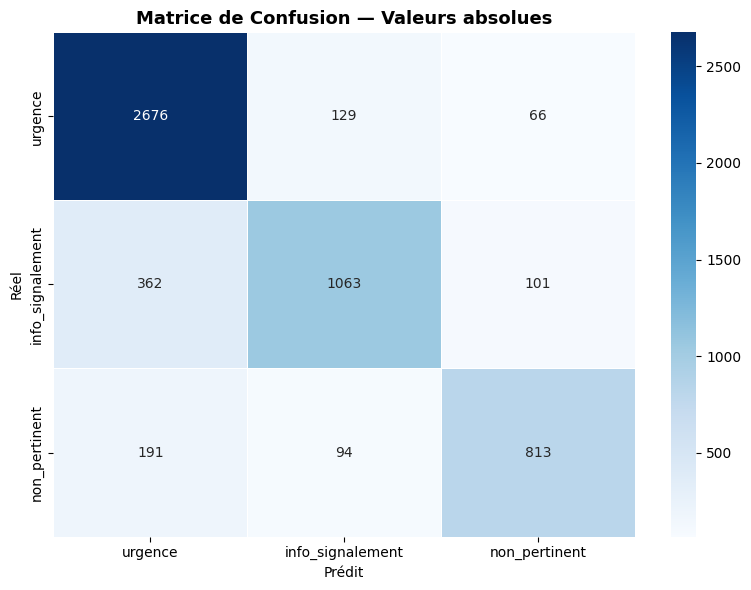

In [8]:
cm = confusion_matrix(labels_test, preds_test)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=NOMS, yticklabels=NOMS,
            linewidths=0.5, ax=ax)
ax.set_title("Matrice de Confusion — Valeurs absolues", fontsize=13, fontweight="bold")
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig("../experiences/resultats/confusion_matrix_absolute.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
cm_norm = cm.astype(float)
row_sums = cm_norm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm_norm / row_sums

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd",
            xticklabels=NOMS, yticklabels=NOMS,
            linewidths=0.5, vmin=0, vmax=1, ax=ax)
ax.set_title("Matrice de Confusion — Normalisée (Rappel)", fontsize=13, fontweight="bold")
ax.set_xlabel("Prédit")
ax.set_ylabel("Réel")
plt.tight_layout()
plt.savefig("../experiences/resultats/confusion_matrix_normalized.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'cm' is not defined

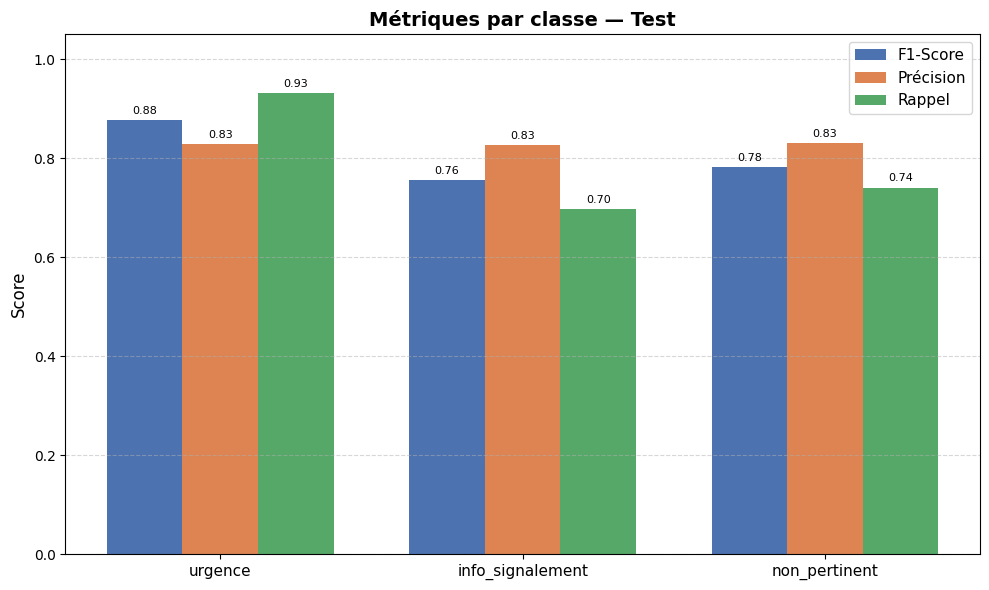

In [10]:
f1_vals = f1_score(labels_test, preds_test, average=None, zero_division=0)
prec_vals = precision_score(labels_test, preds_test, average=None, zero_division=0)
rec_vals = recall_score(labels_test, preds_test, average=None, zero_division=0)

x = np.arange(len(NOMS))
largeur = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - largeur, f1_vals, largeur, label="F1-Score", color="#4C72B0")
bars2 = ax.bar(x, prec_vals, largeur, label="Précision", color="#DD8452")
bars3 = ax.bar(x + largeur, rec_vals, largeur, label="Rappel", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(NOMS, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Métriques par classe — Test", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

# Ajouter les valeurs
for bar in [*bars1, *bars2, *bars3]:
    h = bar.get_height()
    ax.annotate(f"{h:.2f}", xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("../experiences/resultats/metriques_barres.png", dpi=150, bbox_inches="tight")
plt.show()

📊 Comparaison Validation vs Test
          Validation   Test
Accuracy      0.8130 0.8284
F1 Macro      0.7861 0.8053


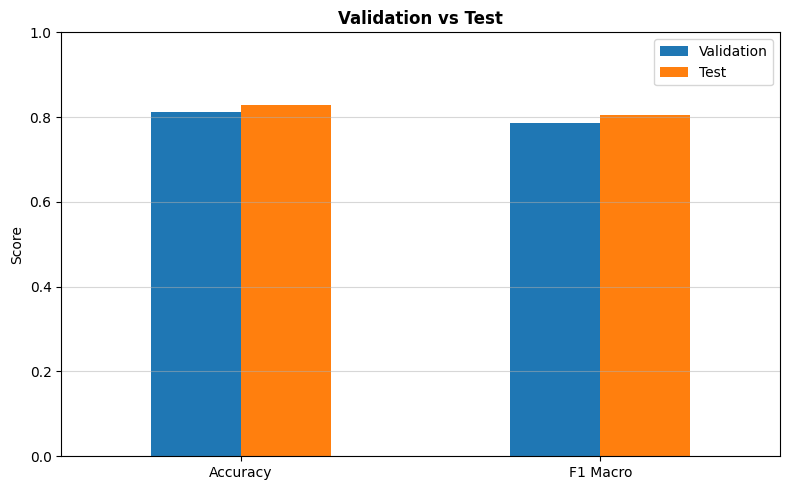

In [11]:
# Métriques validation
acc_val = accuracy_score(labels_val, preds_val)
f1_val = f1_score(labels_val, preds_val, average="macro", zero_division=0)

# Tableau comparatif
df_comp = pd.DataFrame({
    "Validation": [acc_val, f1_val],
    "Test": [acc, f1m],
}, index=["Accuracy", "F1 Macro"])

print("📊 Comparaison Validation vs Test")
print(df_comp.to_string(float_format=lambda x: f"{x:.4f}"))

# Graphique
df_comp.plot(kind="bar", figsize=(8, 5))
plt.title("Validation vs Test", fontweight="bold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.5)
plt.tight_layout()
plt.savefig("../experiences/resultats/val_vs_test.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
print("\n" + "=" * 60)
print("🏆 RÉSUMÉ FINAL")
print("=" * 60)
print(f"   Test Accuracy  : {acc:.4f}")
print(f"   Test F1 Macro  : {f1m:.4f}")
print(f"   Test F1 Weighted : {f1w:.4f}")
print(f"\n   Par classe (F1) :")
for i, nom in enumerate(NOMS):
    print(f"      {nom:<25} : {f1_vals[i]:.4f}")
print(f"\n   ✅ Objectif 83% : {'ATTEINT ! 🎉' if acc >= 0.83 else 'En cours...'}")
print("=" * 60)


🏆 RÉSUMÉ FINAL
   Test Accuracy  : 0.8284
   Test F1 Macro  : 0.8053
   Test F1 Weighted : 0.8247

   Par classe (F1) :
      urgence                   : 0.8774
      info_signalement          : 0.7560
      non_pertinent             : 0.7825

   ✅ Objectif 83% : En cours...
